# Code for processing and clustering of D40-100 data

last updated: 20241127


## Import data and functions

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt
import scrublet 


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set a path to your working directory
directory='/Set/your/path/'
# Save .ha5ad with data before QC filtering
Meta_data_file=directory+'/Written_files/GEX_D40-100_processed_pre-QC.h5ad'
# Save .ha5ad with data after QC filtering and clustering
Results_file=directory+'/Written_files/GEX_D40-D100.h5ad'
# Save .ha5ad with data after QC filtering and clustering
Results_file_DA=directory+'/Written_files/GEX_D40-D100_DA-lineage.h5ad'


In [3]:
# List all files
fileListAll=os.listdir(directory)

namesOfInterest=['D40', 'D100', 'D80']

fileList=[]
# for d in directory:    #add this if concatenating files from different directories
for f in fileListAll:
    if os.path.exists(os.path.join(directory,f,'outs','filtered_feature_bc_matrix.h5')):
        if any([ n in f for n in namesOfInterest]):
            fileList.append(os.path.join(f))  # (d,f) if you want the directory added
            
#print(fileList) 

adatas=[]   

for f in fileList:
    #print(f)
    adata = sc.read_10x_h5(os.path.join(directory,f,'outs','filtered_feature_bc_matrix.h5'))
    adata.uns['name']=f
    #print (adata.uns)
    adata.obs['batch_name']=str(adata.uns['name'])
    #print (adata.obs)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adatas.append(adata)

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbr

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbr

In [4]:
# Concatenate data along the observations axis.
adata=anndata.AnnData.concatenate(*adatas, join='outer', batch_categories=fileList) 

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],


## Adding CHIR99021 concentration as an observation

In [5]:
# Store all multiseq data frames
multiseq_csvs = []

for dirname in fileList:
    if os.path.exists('{}/outs/multiseq_calls.csv'.format(dirname)):
        ms = pd.read_csv('{}/outs/multiseq_calls.csv'.format(dirname), sep=',', index_col=0)
        # Append directory name to barcode so it matches adata later
        ms.index += '-' + dirname
        multiseq_csvs.append(ms)

multiseq_metadata = pd.concat(multiseq_csvs, axis=0)

# Add multiseq metadata to adata.obs
adata.obs = adata.obs.merge(multiseq_metadata, left_index=True, right_index=True, how='left')
adata.obs = adata.obs.drop(['batch'], axis=1)

# Load CHIR data csv
chir_meta = pd.read_csv('Cell_batches_CHIR-conc.csv')
chir_meta = chir_meta.loc[chir_meta['method'] != 'MULTIseq']
chir_meta.drop(['CHIR_conc', 'method'], axis=1, inplace=True)

# Store barcode in a column since it will be lost when emrging
adata.obs['bc'] = adata.obs.index
# Merge with CHIR metadata
adata.obs = adata.obs.merge(chir_meta, left_on='batch_name', right_on='batch_name', how='left')
# Replace weird integer index with barcodes and drop barcode column
adata.obs = adata.obs.set_index(adata.obs['bc'])
adata.obs = adata.obs.drop(['bc'], axis=1)
# Drop index name
adata.obs.index.name = None

# Create a new column for CHIR concentration
adata.obs['CHIR_conc'] = np.nan
# Pull CHIR concentration from rows where we knew it from batch name
adata.obs.loc[~adata.obs['CHIR'].isna(), 'CHIR_conc'] = adata.obs.loc[~adata.obs['CHIR'].isna(), :]['CHIR']
# Pull CHIR concentration from multiseq column where applicable
adata.obs.loc[~adata.obs['assignment'].isna(), 'CHIR_conc'] = adata.obs.loc[~adata.obs['assignment'].isna(), :]['assignment']
# Drop temporary CHIR column
adata.obs = adata.obs.drop(['CHIR'], axis=1)

print(adata.obs)

                                                           batch_name  \
AAACAGCCACAACAGG-1-D40_CH_2_Human                      D40_CH_2_Human   
AAACAGCCATCTAGCA-1-D40_CH_2_Human                      D40_CH_2_Human   
AAACATGCAACAGCCT-1-D40_CH_2_Human                      D40_CH_2_Human   
AAACATGCATCAATCG-1-D40_CH_2_Human                      D40_CH_2_Human   
AAACATGCATTATGCG-1-D40_CH_2_Human                      D40_CH_2_Human   
...                                                               ...   
TTTGCATTCGAAGTGA-1-D40_outgroup-exp_1_Chimp  D40_outgroup-exp_1_Chimp   
TTTGGCTGTATTGTCC-1-D40_outgroup-exp_1_Chimp  D40_outgroup-exp_1_Chimp   
TTTGGTGCATGGCCTG-1-D40_outgroup-exp_1_Chimp  D40_outgroup-exp_1_Chimp   
TTTGTCCCAGGCCTTG-1-D40_outgroup-exp_1_Chimp  D40_outgroup-exp_1_Chimp   
TTTGTCTAGCATTATG-1-D40_outgroup-exp_1_Chimp  D40_outgroup-exp_1_Chimp   

                                            demux_type assignment CHIR_conc  
AAACAGCCACAACAGG-1-D40_CH_2_Human            

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:798: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


## Adding individual identity as an observation

In [6]:
# Load all 3 files as data frames
assn_Human = pd.read_csv('Human_all.assignments2', sep='\t', index_col=0, names=['individual', 'individual_type', 'individual_llr'])
assn_Chimp = pd.read_csv('Chimp_all.assignments2', sep='\t', index_col=0, names=['individual', 'individual_type', 'individual_llr'])
assn_Rhesus = pd.read_csv('Rhesus_all.assignments4', sep='\t', index_col=0, names=['individual', 'individual_type', 'individual_llr'])
# Combine them into a single data frame
assn_all = pd.concat([assn_Human, assn_Chimp, assn_Rhesus], axis=0)
# Merge the combined data with anndata
adata.obs = adata.obs.merge(assn_all, how='left', left_index=True, right_index=True)

## Adding species as an observation

In [7]:
adata.obs['species'] = 'human'
chimp = adata.obs['batch_name'].str.contains('himp')
adata.obs.loc[chimp, 'species'] = 'chimp'
macaque = adata.obs['batch_name'].str.contains('hesus')
adata.obs.loc[macaque, 'species'] = 'macaque'
orangutan = adata.obs['batch_name'].str.contains('rangutan')
adata.obs.loc[orangutan, 'species'] = 'orangutan'

In [8]:
adata.obs['species'].value_counts()

chimp        69138
macaque      55328
human        51667
orangutan    13978
Name: species, dtype: int64

In [9]:
# Rename macaque and orangutan individuals
adata.obs.loc[adata.obs['species'] == 'orangutan', 'individual'] = 'O11045-4593'
adata.obs.loc[adata.obs['individual'] == 'Rhesus_2', 'individual'] = 'ZH26-HS16'
adata.obs.loc[adata.obs['individual'] == 'Rhesus_0', 'individual'] = 'ZG15-M11-10'

In [10]:
adata.obs['individual'].value_counts()

ES_Lyon          32065
H28834           15945
O11045-4593      13978
C8861            11981
C4933            11072
                 ...  
H23555+H9          124
H21792+H23555      119
H21792+H28126      104
H23555+H28126       96
H21194+H23555       87
Name: individual, Length: 71, dtype: int64

## Adding pool type as an observation


In [11]:
adata.obs['batch_name'].value_counts()

D40_outgroup-exp_1_Rhesus    9835
D40_outgroup-exp_2_Rhesus    9450
D40_M0-5_2_Chimp             6874
D80_M_0-8_CNTRL-3_Chimp      6561
D100_M_0-4_Human             6358
                             ... 
D80_M_0-6_CNTRL_Rhesus        803
D100_M_0-6_Rhesus             597
D100_M_0-8_Rhesus             568
D80_M_0-6_CNTRL_Human         470
D40_M0-5_1_Human              107
Name: batch_name, Length: 65, dtype: int64

In [12]:
adata.obs['pool_type'] = 'Interspecies'
Intraspecies = adata.obs['batch_name'].str.contains('_CH|outgroup')
adata.obs.loc[Intraspecies, 'pool_type'] = 'Intraspecies'

In [13]:
adata.obs['pool_type'].value_counts()

Interspecies    103580
Intraspecies     86531
Name: pool_type, dtype: int64

## Adding time point as an observation

In [14]:
adata.obs['time_point'] = 'D16'
D40 = adata.obs['batch_name'].str.contains('D40')
adata.obs.loc[D40, 'time_point'] = 'D40'
D100 = adata.obs['batch_name'].str.contains('D100')
adata.obs.loc[D100, 'time_point'] = 'D100'
D80 = adata.obs['batch_name'].str.contains('D80')
adata.obs.loc[D80, 'time_point'] = 'D80'

In [15]:
adata.obs['time_point'].value_counts()

D40     98404
D80     65139
D100    26568
Name: time_point, dtype: int64

## Adding experiment as an observation

In [16]:
adata.obs['experiment'] = 'first_experiment'
outgroup_experiment = adata.obs['batch_name'].str.contains('outgroup')
adata.obs.loc[outgroup_experiment, 'experiment'] = 'outgroup_experiment'
replicate_experiment = adata.obs['batch_name'].str.contains('M0-5|M_0-5')
adata.obs.loc[replicate_experiment, 'experiment'] = 'replicate_experiment'
rotenone_experiment = adata.obs['batch_name'].str.contains('CNTRL')
adata.obs.loc[rotenone_experiment, 'experiment'] = 'rotenone_experiment'

In [17]:
adata.obs['experiment'].value_counts()

first_experiment        69568
outgroup_experiment     60106
rotenone_experiment     38487
replicate_experiment    21950
Name: experiment, dtype: int64

## Adding 10x day as an observation

In [18]:
adata.obs['day_10x'] = 'Run_20211206'
Run_20220316 = adata.obs['batch_name'].str.contains('D100_M')
adata.obs.loc[Run_20220316, 'day_10x'] = 'Run_20220316'
Run_20221123 = adata.obs['batch_name'].str.contains('_CNTRL_')
adata.obs.loc[Run_20221123, 'day_10x'] = 'Run_20221123'
Run_20230126 = adata.obs['batch_name'].str.contains('outgroup|_CNTRL-2|_CNTRL-3')
adata.obs.loc[Run_20230126, 'day_10x'] = 'Run_20230126'

In [19]:
adata.obs['day_10x'].value_counts()

Run_20230126    85704
Run_20211206    64950
Run_20220316    26568
Run_20221123    12889
Name: day_10x, dtype: int64

## Adding 10x lane as an observation

In [20]:
adata.obs['lane'] = 'Lane1'
Lane2 = adata.obs['batch_name'].str.contains('CH_2')
adata.obs.loc[Lane2, 'lane'] = 'Lane2'
Lane3 = adata.obs['batch_name'].str.contains('CH_3')
adata.obs.loc[Lane3, 'lane'] = 'Lane3'
Lane4 = adata.obs['batch_name'].str.contains('M_1')
adata.obs.loc[Lane4, 'lane'] = 'Lane4'
Lane5 = adata.obs['batch_name'].str.contains('M_2')
adata.obs.loc[Lane5, 'lane'] = 'Lane5'
Lane6 = adata.obs['batch_name'].str.contains('M_3')
adata.obs.loc[Lane6, 'lane'] = 'Lane6'
Lane7 = adata.obs['batch_name'].str.contains('M0-5_1')
adata.obs.loc[Lane7, 'lane'] = 'Lane7'
Lane8 = adata.obs['batch_name'].str.contains('M0-5_2')
adata.obs.loc[Lane8, 'lane'] = 'Lane8'

Lane9 = adata.obs['batch_name'].str.contains('M_0-4')
adata.obs.loc[Lane9, 'lane'] = 'Lane9'
Lane10 = adata.obs['batch_name'].str.contains('M_0-6')
adata.obs.loc[Lane10, 'lane'] = 'Lane10'
Lane11 = adata.obs['batch_name'].str.contains('M_0-8')
adata.obs.loc[Lane11, 'lane'] = 'Lane11'
Lane12 = adata.obs['batch_name'].str.contains('M_0-5')
adata.obs.loc[Lane12, 'lane'] = 'Lane12'

Lane13 = adata.obs['batch_name'].str.contains('M_0-6_CNTRL_')
adata.obs.loc[Lane13, 'lane'] = 'Lane13'
Lane14 = adata.obs['batch_name'].str.contains('M_0-8_CNTRL_')
adata.obs.loc[Lane14, 'lane'] = 'Lane14'

Lane15 = adata.obs['batch_name'].str.contains('D40_outgroup-exp_1')
adata.obs.loc[Lane15, 'lane'] = 'Lane15'
Lane16 = adata.obs['batch_name'].str.contains('D40_outgroup-exp_2')
adata.obs.loc[Lane16, 'lane'] = 'Lane16'
Lane17 = adata.obs['batch_name'].str.contains('D80_outgroup-exp_1')
adata.obs.loc[Lane17, 'lane'] = 'Lane17'
Lane18 = adata.obs['batch_name'].str.contains('D80_outgroup-exp_2')
adata.obs.loc[Lane18, 'lane'] = 'Lane18'
Lane19 = adata.obs['batch_name'].str.contains('D80_outgroup-exp_3')
adata.obs.loc[Lane19, 'lane'] = 'Lane19'
Lane20 = adata.obs['batch_name'].str.contains('M_0-8_CNTRL-2')
adata.obs.loc[Lane20, 'lane'] = 'Lane20'
Lane21 = adata.obs['batch_name'].str.contains('M_0-8_CNTRL-3')
adata.obs.loc[Lane21, 'lane'] = 'Lane21'

In [21]:
adata.obs['lane'].value_counts()

Lane15    17099
Lane16    16355
Lane21    13734
Lane20    11864
Lane3     11014
Lane14    10234
Lane8     10143
Lane19     9079
Lane18     8907
Lane17     8666
Lane9      8128
Lane5      7922
Lane2      7872
Lane6      7708
Lane1      7539
Lane11     7146
Lane4      6431
Lane7      6321
Lane10     5808
Lane12     5486
Lane13     2655
Name: lane, dtype: int64

In [22]:
adata.obs

,batch_name,demux_type,assignment,CHIR_conc,individual,individual_type,individual_llr,species,pool_type,time_point,experiment,day_10x,lane
AAACAGCCACAACAGG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H20961,S,436.225447,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2
AAACAGCCATCTAGCA-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.4,C.4,H21792,S,636.853818,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2
AAACATGCAACAGCCT-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H29089,S,354.373208,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2
AAACATGCATCAATCG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H20961,S,215.154958,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2
AAACATGCATTATGCG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H28126,S,392.516627,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCATTCGAAGTGA-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C8861,S,8.519840,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15
TTTGGCTGTATTGTCC-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C40300,S,16.480662,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15
TTTGGTGCATGGCCTG-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C40210,S,0.471806,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15
TTTGTCCCAGGCCTTG-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C8861,S,3.700542,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15


In [23]:
adata.write(Meta_data_file)

## Pre-processing of data

### Remove doublets


In [24]:
# load .h5ad with D40-100 data 
adata = sc.read_h5ad(directory+'/Written_files/D40-100_GEX_processed_pre-QC.h5ad')

In [25]:
print("before doublet removal:")
print(adata)

# Get names of doublets
Doublets_to_drop = adata.obs.loc[(adata.obs['individual_type'] == 'D'),:].index
# Remove these cells from anndata
adata = adata[~adata.obs.index.isin(Doublets_to_drop),:]

print("after doublet removal:")
print(adata)

before doublet removal:
AnnData object with n_obs × n_vars = 190111 × 81844
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'time_point', 'experiment', 'day_10x', 'lane'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gene_ids-D100_M_0-6_Human', 'feature_types-D100_M_0-6_Human', 'genome-D100_M_0-6_Human', 'gen

### Remove H28834 D100 cells

In [26]:
adata

View of AnnData object with n_obs × n_vars = 160300 × 81844
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'time_point', 'experiment', 'day_10x', 'lane'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gene_ids-D100_M_0-6_Human', 'feature_types-D100_M_0-6_Human', 'genome-D100_M_0-6_Human', 'gene_ids-D100_M_0-6

In [27]:
# Get names of bad cells
cells_to_drop = adata.obs.loc[(adata.obs['individual'] == 'H28834') & (adata.obs['time_point'] == 'D100'),:].index
# Remove these cells from anndata
adata = adata[~adata.obs.index.isin(cells_to_drop),:]


print("after removing H28834:")
print(adata)

after removing H28834:
View of AnnData object with n_obs × n_vars = 147807 × 81844
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'time_point', 'experiment', 'day_10x', 'lane'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gene_ids-D100_M_0-6_Human', 'feature_types-D100_M_0-6_Human', 'genome-D100_M_0-6_Human

### Quality control (QC) filtering 

In [28]:
# Basic filtering
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

# Annotate varibles for mitochondrial and ribosomal genes
mito_genes=[name for name in adata.var_names if name in ['ND1','ND2','ND4L','ND4','ND5','ND6','ATP6','ATP8','CYTB','COX1','COX2','COX3'] or 'MT-' in name]
ribo_genes=[name for name in adata.var_names if name.startswith('RPS') or name.startswith('RPL') ]

# For each cell compute fraction of counts in mito genes vs. all genes
adata.obs['percent_mito'] = np.sum(
    adata[:, mito_genes].X, axis=1) / np.sum(adata.X, axis=1)
adata.obs['percent_ribo'] = np.sum(
adata[:, ribo_genes].X, axis=1) / np.sum(adata.X, axis=1)

# Add the total counts per cell as observations-annotation to adata
adata.obs['n_counts'] = adata.X.sum(axis=1)


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:140: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


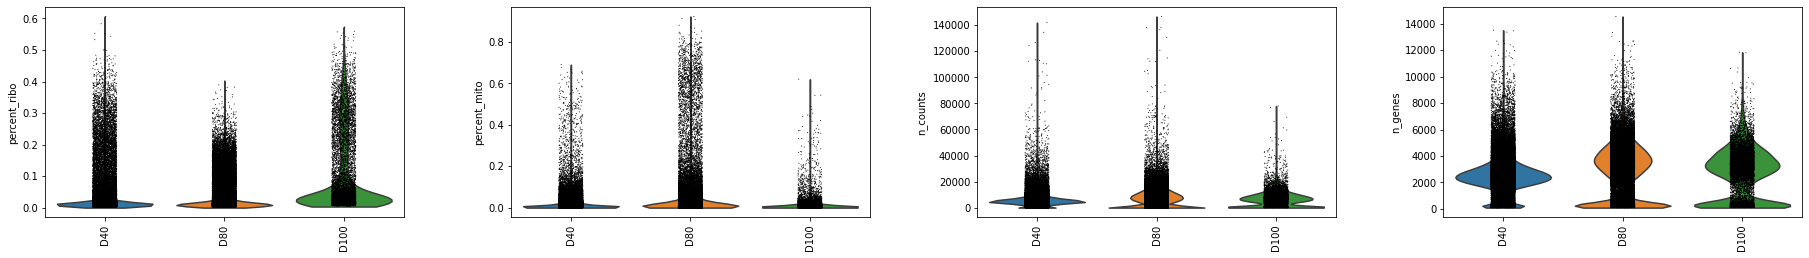

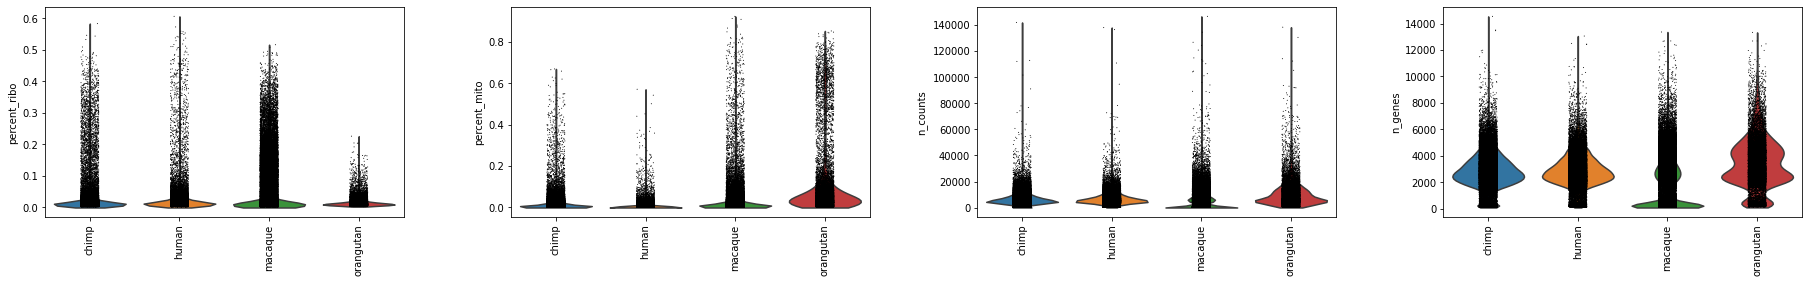

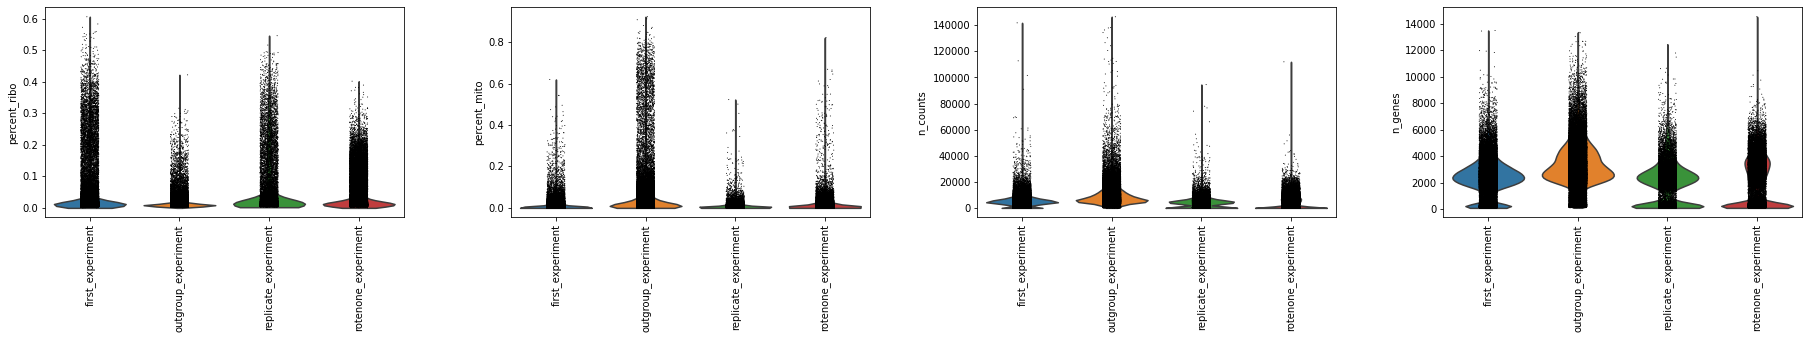

In [29]:
# Pre-filtering QC plots
sc.pl.violin(adata,groupby='time_point',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='QC_metrics')

sc.pl.violin(adata,groupby='species',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='QC_metrics')

sc.pl.violin(adata,groupby='experiment',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='QC_metrics')

In [30]:
# Filter cells and based on mitochondrial fractions
adata._inplace_subset_obs(adata.obs['percent_mito']<.15)
adata._inplace_subset_obs(adata.obs['percent_ribo']<.1)

# Get rid of mito genes
adata._inplace_subset_var(~adata.var.index.isin(mito_genes))

# Filter cells and based on counts
sc.pp.filter_genes(adata,min_cells=10) 
sc.pp.filter_cells(adata,min_counts=1000)
sc.pp.filter_cells(adata,min_genes=1000)
sc.pp.filter_cells(adata,max_genes=7500)


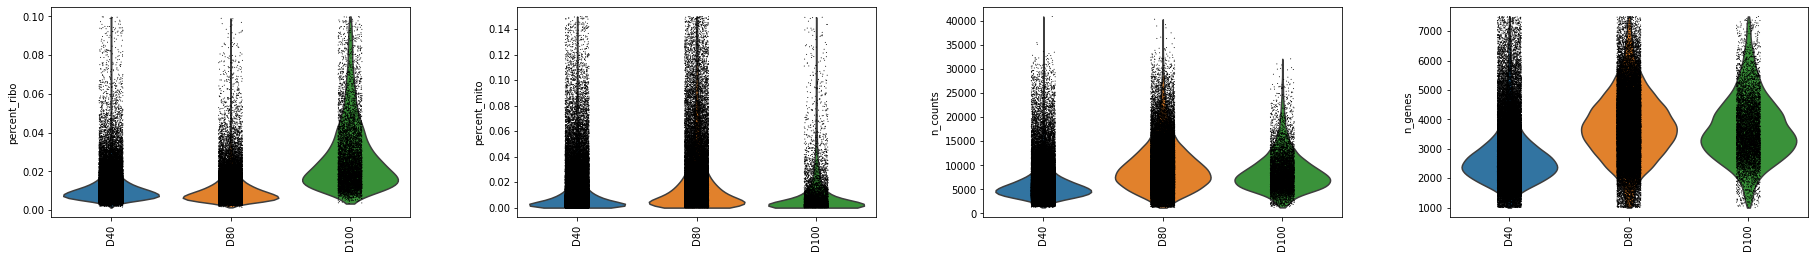

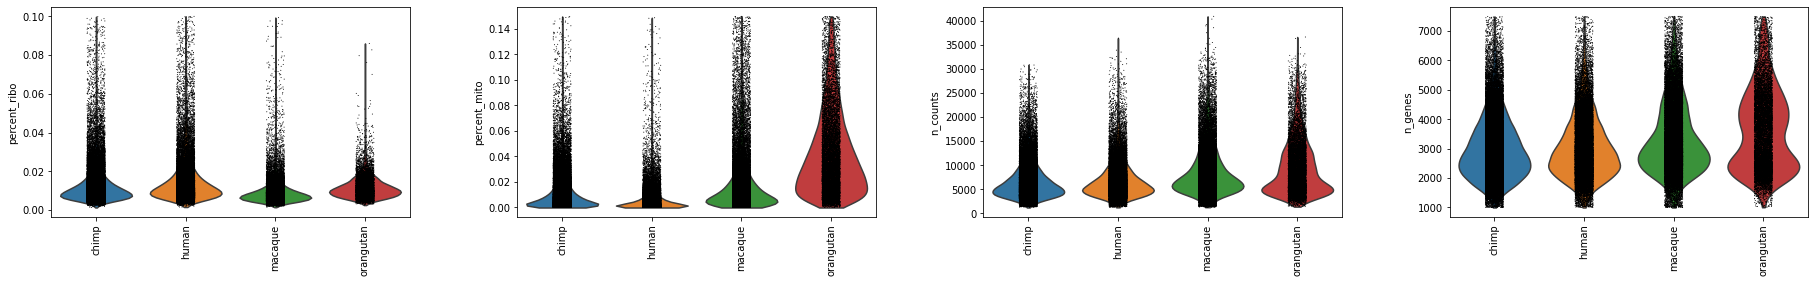

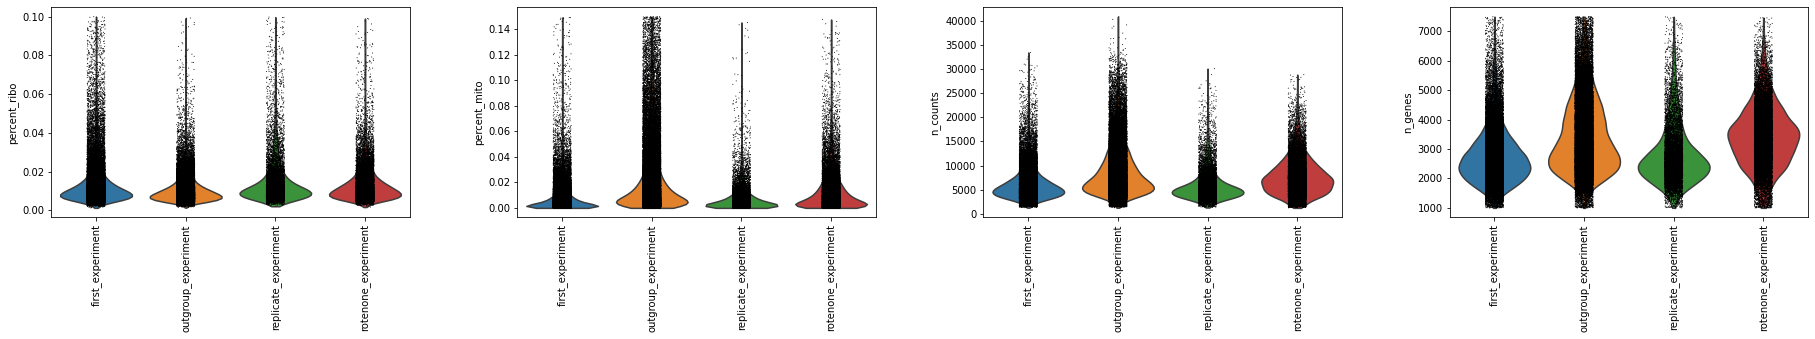

after QC filtering:
AnnData object with n_obs × n_vars = 114859 × 51861
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'time_point', 'experiment', 'day_10x', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gene_ids-D100_M_0-6_Human', 'feature_types

In [31]:
# Post-filtering QC plots

sc.pl.violin(adata,groupby='time_point',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='QC_metrics')

sc.pl.violin(adata,groupby='species',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='QC_metrics')

sc.pl.violin(adata,groupby='experiment',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='QC_metrics')

print("after QC filtering:")
print(adata)

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


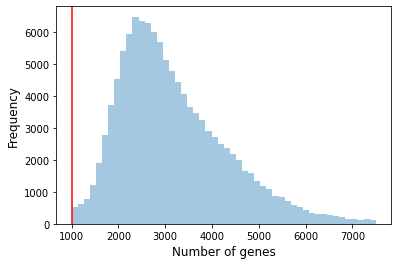

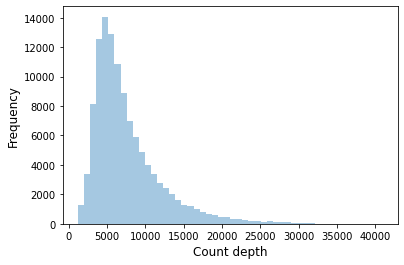

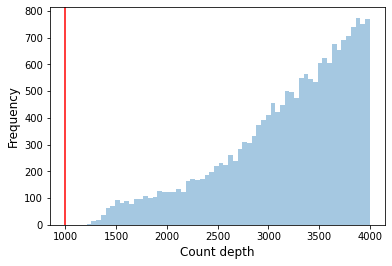

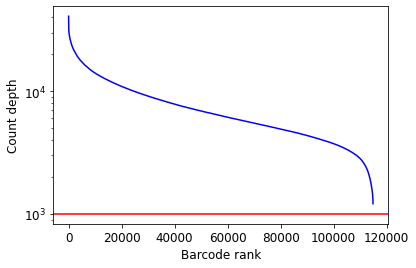

In [32]:
# Histograms of the distrubution of UMI counts and gene numbers

Hist2 = seaborn.distplot(adata.obs['n_genes'], kde=False)
Hist2.set_xlabel("Number of genes", fontsize=12)
Hist2.set_ylabel("Frequency", fontsize=12)
Hist2.axvline(1000, 0,1, color='red')

plt.show()

Hist1 = seaborn.distplot(adata.obs['n_counts'], kde=False)
Hist1.set_xlabel("Count depth", fontsize=12)
Hist1.set_ylabel("Frequency", fontsize=12)

plt.show()

Hist3 = seaborn.distplot(adata.obs['n_counts'][adata.obs['n_counts']<4000], kde=False, bins=60)
Hist3.set_xlabel("Count depth", fontsize=12)
Hist3.set_ylabel("Frequency", fontsize=12)
Hist3.axvline(1000, 0,1, color='red')

plt.show()


# Where's the elbow of the count depht distribution?

count_data = adata.obs['n_counts'].copy()
count_data.sort_values(inplace=True, ascending=False)
order =  range(1, len(count_data)+1)
llplot = plt.semilogy(order, count_data, 'b-')
plt.gca().axhline(1000, 0,1, color='red')
plt.xlabel("Barcode rank", fontsize=12)
plt.ylabel("Count depth", fontsize=12)
plt.tick_params(labelsize=12)
plt.plot()

plt.show()

## Normalization, log transformation, scaling

In [33]:
adata.raw=adata

# Total-count normalize (library-size correct) the data matrix 𝐗 to 10,000 reads per cell, so that counts become comparable among cells.
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transform the data
sc.pp.log1p(adata)

In [34]:
# Identify highly-variable genes (HVGs)
(sc.pp.highly_variable_genes(adata,n_top_genes=15000,batch_key='batch_name',subset=False))

# Filter highly variable genes
#adata = adata[:, adata.var.highly_variable]

# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. 
#sc.pp.regress_out(adata, ['n_counts', 'percent_mito'])

# Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-

## Principal component analysis

In [35]:
# Principal component analysis - computes PCA coordinates, loadings and variance decomposition
sc.pp.pca(adata,n_comps=50) 

## Computing and embedding the neighborhood graph

In [36]:
# To obtain clusters with merged species identities BBKNN is used as an alternative to scanpy.pp.neighbors(), with both functions creating a neighbour graph
bbknn.bbknn(adata,batch_key='species',n_pcs=50,neighbors_within_batch=3)

# Cluster cells using the Leiden algorithm
sc.tl.leiden(adata,resolution=1.5)

# Embed the neighborhood graph using UMAP
sc.tl.umap(adata,spread=2)

# Project the leiden clusters onto the UMAP
sc.pl.umap(adata,color=['leiden'])

### Indentify low qulaity clusters and clusteres marked by high ER stress

*Note*: additional information can be obtained by running **sc.tl.rank_genes_groups** on the logarithmized data.

You can then show then print the top 100 ranked genes by cluster by running:

    df = pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(100) 

    df.to_csv('D40-D100_before_removing_ER_stress.csv')

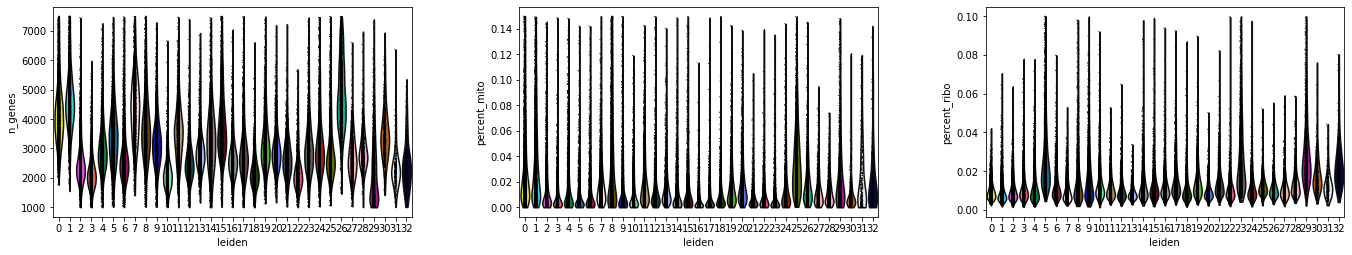

In [38]:
# Make violin plots numbers of genes per cell and percent mitochondrial and riobosomal reads
sc.pl.violin(adata, ['n_genes', 'percent_mito', 'percent_ribo'], groupby='leiden')


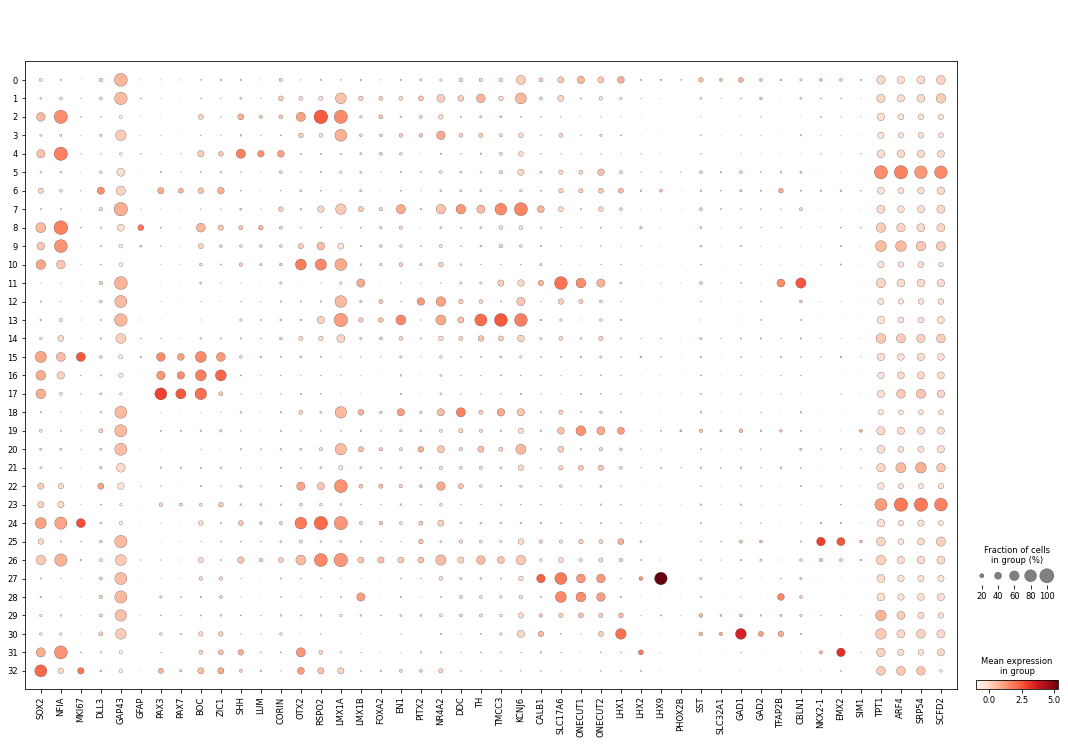

In [75]:
marker_genes = [
   'SOX2','NFIA','MKI67','DLL3','GAP43','GFAP', 
    'PAX3', 'PAX7', 'BOC', 'ZIC1', 'SHH', 'LUM', 'CORIN',
    'OTX2', 'RSPO2', 'LMX1A', 'LMX1B', 'FOXA2', 'EN1', 
    'PITX2', 'NR4A2', 'DDC', 'TH', 'TMCC3', 'KCNJ6',
    'CALB1', 'SLC17A6', 'ONECUT1', 'ONECUT2', 'LHX1', 'LHX2','LHX9',
    'PHOX2B', 'SST', 'SLC32A1','GAD1', 'GAD2', 'TFAP2B', 'CBLN1', 
    'NKX2-1', 'EMX2', 'SIM1',
    'TPT1','ARF4','SRP54','SCFD2'
    
]


sc.pl.dotplot(adata, marker_genes, use_raw=False,  groupby='leiden')

Text(0, 0.5, 'proportion')

<Figure size 432x288 with 0 Axes>

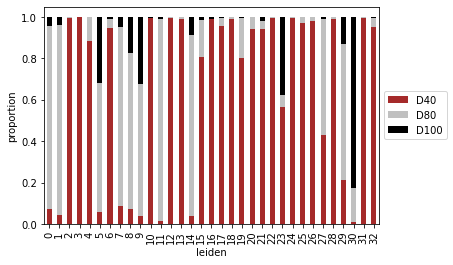

<Figure size 432x288 with 0 Axes>

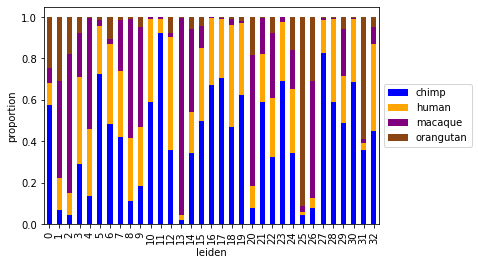

In [40]:
# Setting colors for time point
adata.uns['time_point_colors'] = ['brown','silver', 'black']
time_point_colors = adata.uns["time_point_colors"] 

# Make bar chart to see how cells of different time points are distributed across time points
f = plt.figure()
df_plot = adata.obs.groupby(['leiden', 'time_point']).size().reset_index().pivot(columns='time_point', index='leiden', values=0).apply(lambda g: g / g.sum(),1)
ax = df_plot.plot(kind='bar', color=time_point_colors, legend=False,stacked=True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

# Setting colors for species
adata.uns['species_colors'] = ['blue','orange', 'purple','saddlebrown']
species_colors = adata.uns["species_colors"] 

# Make bar chart to see how cells from different species are distributed across time points
f = plt.figure()
df_plot = adata.obs.groupby(['leiden', 'species']).size().reset_index().pivot(columns='species', index='leiden', values=0).apply(lambda g: g / g.sum(),1)
ax = df_plot.plot(kind='bar', color=species_colors, legend=False,stacked=True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

## Remove ER-stress clusters and low quality clusters

In [43]:
# Remove the low quality clusters that were identified 
adata = adata[~adata.obs['leiden'].isin(['5','23', '29'])]

print(adata)

In [79]:
# Redo principal component analysis - computes PCA coordinates, loadings and variance decomposition
sc.pp.pca(adata,n_comps=50) 

In [82]:
# To obtain clusters with merged species identities BBKNN is used as an alternative to scanpy.pp.neighbors(), with both functions creating a neighbour graph
bbknn.bbknn(adata,batch_key='species',n_pcs=50,neighbors_within_batch=3)

# Cluster cells using the Leiden algorithm
sc.tl.leiden(adata,resolution=1.5)

# Embed the neighborhood graph using UMAP
sc.tl.umap(adata,spread=2)

# Project the leiden clusters onto the UMAP
sc.pl.umap(adata,color=['leiden'])

## Subsetting DA lineage cells 

In [ ]:
adata_DA = adata_subset[adata_subset.obs['supervised_name'].isin(['DA neurons',  'Ventral FB/MB progenitors','DA/STN neurons, immature', 'STN neurons', 
                                                        ])]

In [ ]:
print(adata_DA)

In [ ]:
sc.pp.pca(adata_DA)
sc.pl.pca(adata_DA, use_raw=False,  color=(['GAP43', 'NFIA', 'LMX1A', 'TH', 'EN1', 'NR4A2',
                                   'PITX2',  'TMCC3',  ]), color_map=matplotlib.cm.Blues)

In [ ]:
sc.pl.pca(adata_DA, use_raw=False,  color=(['GAP43', 'NFIA', 'LMX1A', 'TH']), color_map=matplotlib.cm.Blues)

In [ ]:
sc.pl.pca(adata_DA, color=('time_point',  'CHIR_conc', 'experiment', 'species'))

In [ ]:
sc.pl.pca(adata_DA, color=('species'))

### Species based integration

In [ ]:
bbknn.bbknn(adata_DA,batch_key='species',n_pcs=50,neighbors_within_batch=3)
sc.tl.leiden(adata_DA,resolution=1)
sc.tl.umap(adata_DA,spread=2)

In [ ]:
sc.pl.umap(adata_DA,color='leiden')
sc.pl.umap(adata_DA,color='batch_name')
sc.pl.umap(adata_DA,color='species')
sc.pl.umap(adata_DA,color='experiment')
sc.pl.umap(adata_DA,color='time_point')
sc.pl.umap(adata_DA,color='CHIR_conc')
sc.pl.umap(adata_DA,color='percent_mito')
sc.pl.umap(adata_DA,color='n_genes')
sc.pl.umap(adata_DA,color='n_counts')
#sc.pl.umap(adata_DA_subset, color='CHIR_conc_singlet')
#sc.pl.umap(adata_DA_subset, color='Individual_singlet')
sc.pl.umap(adata_DA, color='individual')
sc.pl.umap(adata_DA, color='individual_type')

In [ ]:
for species in adata_DA.obs['species'].unique():
    sc.pl.umap(adata_DA, color='species', groups=[species])

In [ ]:
f = plt.figure()
df_plot = adata_DA.obs.groupby(['leiden', 'species']).size().reset_index().pivot(columns='species', index='leiden', values=0).apply(lambda g: g / g.sum(),1)
ax = df_plot.plot(kind='bar', legend=False,stacked=True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')
#ax.get_figure().savefig(os.path.join(sc.settings.figdir,'supervisedVbatchBar.pdf'), bbox_inches="tight")

In [ ]:
adata_DA.obs.groupby('leiden').size()

In [ ]:
DA_list=[
'GAP43', 'SOX2','MKI67', 'DLL3',
'LMX1A', 'OTX2', 'FOXA2','EN1',
'TH', 'NR4A2', 'DDC', 'TMCC3',
'KCNJ6', 'CALB1','KCNMB2','PITX2']

sc.pl.umap(adata_DA,color=DA_list,use_raw=False, palette="Set2", color_map=matplotlib.cm.Blues)

In [ ]:
#sc.pl.dotplot(adata_subset, summary_markers, use_raw=False,  groupby='supervised_name', 
              #save='D40-100_dotplot')

sc.pl.dotplot(adata_DA,DA_list, groupby='leiden', use_raw=False)

### Batch based intergration

In [ ]:
bbknn.bbknn(adata_DA,batch_key='batch_name',n_pcs=50,neighbors_within_batch=1)
sc.tl.leiden(adata_DA,resolution=1)
sc.tl.umap(adata_DA,spread=2)

In [ ]:
sc.pl.umap(adata_DA,color='leiden')
sc.pl.umap(adata_DA,color='batch_name')
sc.pl.umap(adata_DA,color='species')
sc.pl.umap(adata_DA,color='experiment')
sc.pl.umap(adata_DA,color='time_point')
sc.pl.umap(adata_DA,color='CHIR_conc')
sc.pl.umap(adata_DA,color='percent_mito')
sc.pl.umap(adata_DA,color='n_genes')
sc.pl.umap(adata_DA,color='n_counts')
#sc.pl.umap(adata_DA_subset, color='CHIR_conc_singlet')
#sc.pl.umap(adata_DA_subset, color='Individual_singlet')
sc.pl.umap(adata_DA, color='individual')
sc.pl.umap(adata_DA, color='individual_type')

In [ ]:
f = plt.figure()
df_plot = adata_DA.obs.groupby(['leiden', 'species']).size().reset_index().pivot(columns='species', index='leiden', values=0).apply(lambda g: g / g.sum(),1)
ax = df_plot.plot(kind='bar', legend=False,stacked=True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')
#ax.get_figure().savefig(os.path.join(sc.settings.figdir,'supervisedVbatchBar.pdf'), bbox_inches="tight")

In [ ]:
sc.pl.umap(adata_DA,color=DA_list,use_raw=False, palette="Set2", color_map=matplotlib.cm.Blues)

In [ ]:
sc.pl.dotplot(adata_DA,  DA_list, groupby='leiden', use_raw=False)